# Customer Comments - Benchmark Text Classification và MLP NumPy

Notebook này huấn luyện và đối chuẩn 4 mô hình phân loại nhị phân trên dataset `Womens Clothing E-Commerce Reviews.csv`:

- **Logistic Regression**: baseline tuyến tính
- **Multinomial Naive Bayes**: mô hình xác suất cổ điển cho text
- **Random Forest**: ensemble phi tuyến
- **MLP đa tầng thuần NumPy**: `1000 -> 64 -> 16 -> 1`

Input của mô hình là văn bản review đã làm sạch, được biểu diễn bằng **TF-IDF 1,000 chiều**. Vectorizer chỉ được `fit` trên tập train để chống rò rỉ dữ liệu.


## 1. Kiểm tra thư viện

Notebook không tự động cài package. Nếu cell này báo thiếu thư viện, hãy cài trong môi trường Python/Jupyter đang dùng rồi chạy lại notebook.


In [20]:
import importlib.util

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

missing = [pip_name for module_name, pip_name in required_modules.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    raise ModuleNotFoundError(
        "Notebook cần các package sau: " + ", ".join(missing) +
        ". Cài gợi ý: pip install numpy pandas scikit-learn matplotlib"
    )

import re
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Data

Cell này tìm dataset theo đường dẫn tương đối `../data/Womens Clothing E-Commerce Reviews.csv` khi chạy notebook từ thư mục `notebook`. Một vài đường dẫn dự phòng được thêm để notebook vẫn chạy được nếu kernel đang đứng ở thư mục gốc project.


In [21]:
candidate_paths = [
    Path("../data/Womens Clothing E-Commerce Reviews.csv"),
    Path("data/Womens Clothing E-Commerce Reviews.csv"),
    Path("src/Assigment 03/customer_comments/data/Womens Clothing E-Commerce Reviews.csv"),
]

DATA_PATH = None
for candidate in candidate_paths:
    if candidate.exists():
        DATA_PATH = candidate.resolve()
        break

if DATA_PATH is None:
    searched = "; ".join(str(path) for path in candidate_paths)
    raise FileNotFoundError("Không tìm thấy dataset. Các đường dẫn đã thử: " + searched)

df_raw = pd.read_csv(DATA_PATH)

unnamed_cols = [col for col in df_raw.columns if str(col).startswith("Unnamed")]
if unnamed_cols:
    df_raw = df_raw.drop(columns=unnamed_cols)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head())


Dataset path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/data/Womens Clothing E-Commerce Reviews.csv
Shape: 23,486 rows x 10 columns


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,5,1,6,General,Tops,Blouses


In [22]:
# ============================================================
# FIGURE OUTPUT
# ============================================================

FIGURE_DIR = DATA_PATH.parent.parent / "report" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename):
    output_path = FIGURE_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path


## 3. Khảo sát cấu trúc dữ liệu

Phần này kiểm tra kiểu dữ liệu, missing values, duplicate rows, phân phối nhãn `Recommended IND` và vài cột mô tả sản phẩm/review.


In [23]:
print("Data types:")
display(df_raw.dtypes.to_frame("dtype"))

audit = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean() * 100,
    "unique_values": df_raw.nunique(dropna=False),
})
print(f"Duplicate rows: {df_raw.duplicated().sum():,}")
display(audit)

target_summary = df_raw["Recommended IND"].value_counts().sort_index().to_frame("count")
target_summary["percent"] = target_summary["count"] / len(df_raw) * 100
display(target_summary)

display(df_raw.describe(include="all").T)


Data types:


,dtype
Clothing ID,int64
Age,int64
Title,str
Review Text,str
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,str
Department Name,str
Class Name,str


Duplicate rows: 21


,missing_count,missing_percent,unique_values
Clothing ID,0,0.0000,1206
Age,0,0.0000,77
Title,3810,16.2224,13994
Review Text,845,3.5979,22635
Rating,0,0.0000,5
Recommended IND,0,0.0000,2
Positive Feedback Count,0,0.0000,82
Division Name,14,0.0596,4
Department Name,14,0.0596,7
Class Name,14,0.0596,21


,count,percent
Recommended IND,,
0,4172,17.7638
1,19314,82.2362


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,NaN,NaN,NaN,918.1187,203.299,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.1985,12.2795,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196,1.11,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.8224,0.3822,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.5359,5.7022,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class Name,23472,20,Dresses,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Làm sạch văn bản

Notebook dùng `Title + Review Text` làm input văn bản. Các bước làm sạch gồm: lowercase, loại HTML/URL/ký tự không phải chữ, chuẩn hóa khoảng trắng và loại review rỗng sau xử lý.


In [24]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df = df_raw.copy()
df["Title"] = df["Title"].fillna("")
df["Review Text"] = df["Review Text"].fillna("")
df["full_text"] = (df["Title"].astype(str) + " " + df["Review Text"].astype(str)).str.strip()
df["clean_text"] = df["full_text"].apply(clean_text)
df["word_count"] = df["clean_text"].str.split().apply(len)
df["char_count"] = df["clean_text"].str.len()

df_model = df[df["clean_text"].str.len() > 0].copy()
df_model["label"] = df_model["Recommended IND"].astype(int)

print(f"Rows ban đầu: {len(df_raw):,}")
print(f"Rows còn lại sau khi bỏ text rỗng: {len(df_model):,}")
display(df_model[["Title", "Review Text", "clean_text", "label", "word_count"]].head())


Rows ban đầu: 23,486
Rows còn lại sau khi bỏ text rỗng: 22,642


,Title,Review Text,clean_text,label,word_count
0,,Absolutely wonderful - silky and sexy and comfortable,absolutely wonderful silky and sexy and comfortable,1,7
1,,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",love this dress it s sooo pretty i happened to find it in a store and i m glad i did bc i never would have ordered i...,1,64
2,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,some major design flaws i had such high hopes for this dress and really wanted it to work for me i initially ordered...,0,101
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",my favorite buy i love love love this jumpsuit it s fun flirty and fabulous every time i wear it i get nothing but g...,1,26
4,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,flattering shirt this shirt is very flattering to all due to the adjustable front tie it is the perfect length to we...,1,38


## 5. EDA trực quan

Các biểu đồ dưới đây giúp nhìn nhanh phân phối nhãn, rating, độ dài review và những từ xuất hiện nhiều trong văn bản đã làm sạch.


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/report/figures/customer_comments_eda_overview.png


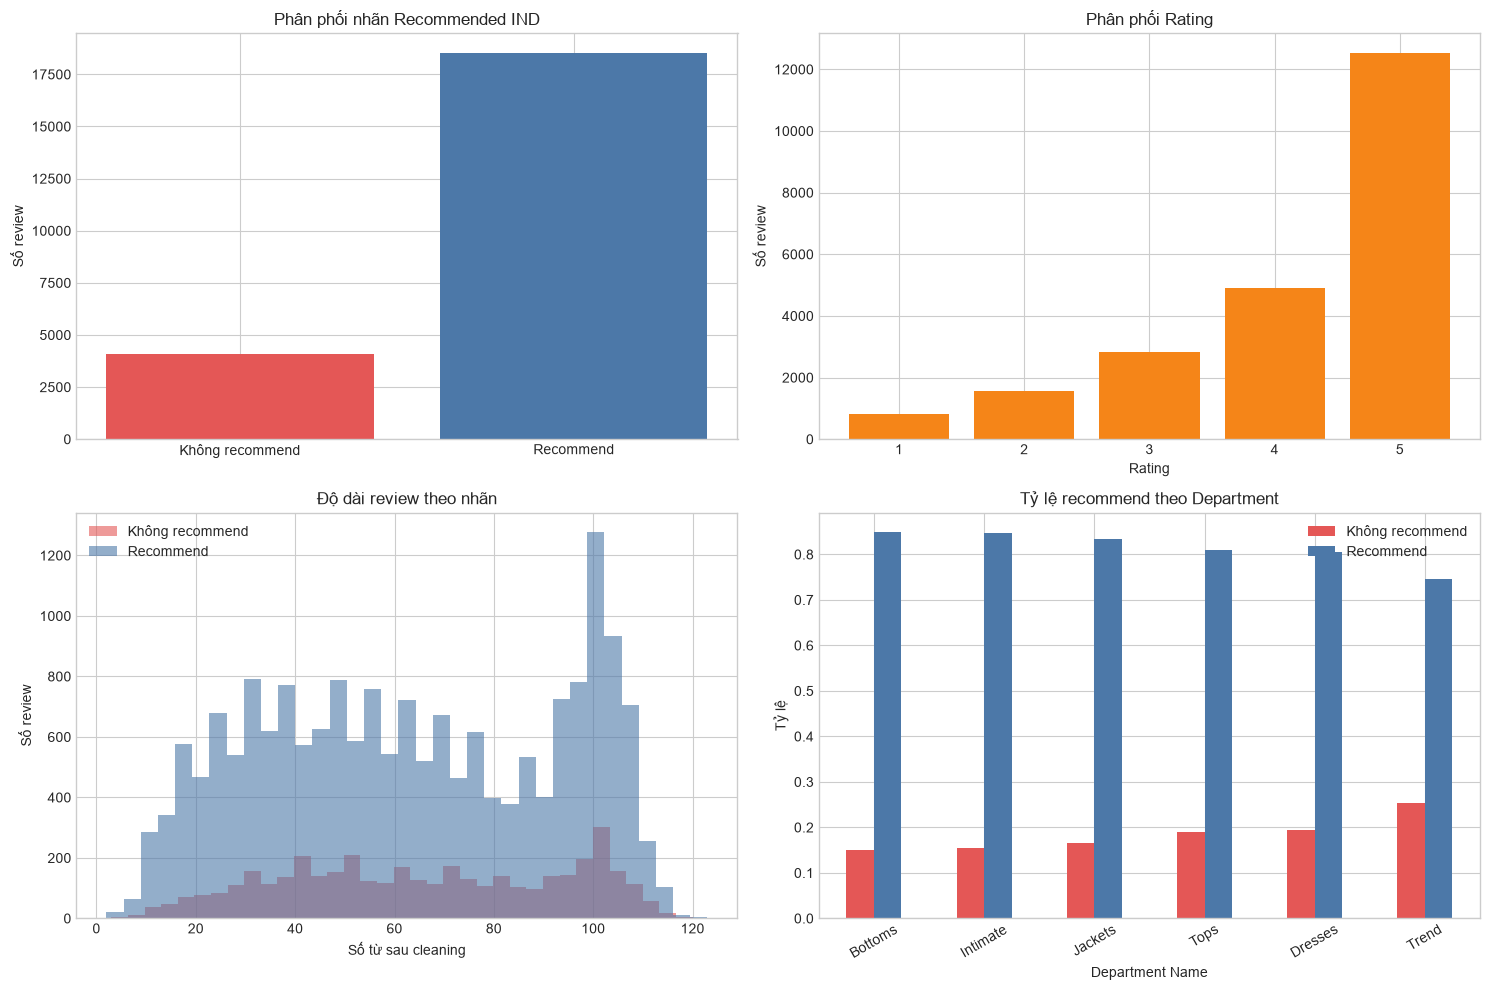

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

label_counts = df_model["label"].value_counts().sort_index()
axes[0].bar(["Không recommend", "Recommend"], label_counts.values, color=["#E45756", "#4C78A8"])
axes[0].set_title("Phân phối nhãn Recommended IND")
axes[0].set_ylabel("Số review")

rating_counts = df_model["Rating"].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values, color="#F58518")
axes[1].set_title("Phân phối Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Số review")

for label, name, color in [(0, "Không recommend", "#E45756"), (1, "Recommend", "#4C78A8")]:
    subset = df_model.loc[df_model["label"] == label, "word_count"]
    axes[2].hist(subset, bins=35, alpha=0.6, label=name, color=color)
axes[2].set_title("Độ dài review theo nhãn")
axes[2].set_xlabel("Số từ sau cleaning")
axes[2].set_ylabel("Số review")
axes[2].legend()

department_label_rate = pd.crosstab(df_model["Department Name"], df_model["label"], normalize="index")
department_label_rate = department_label_rate.sort_values(1, ascending=False)
department_label_rate.plot(kind="bar", ax=axes[3], color=["#E45756", "#4C78A8"])
axes[3].set_title("Tỷ lệ recommend theo Department")
axes[3].set_xlabel("Department Name")
axes[3].set_ylabel("Tỷ lệ")
axes[3].legend(["Không recommend", "Recommend"])
axes[3].tick_params(axis="x", rotation=30)

plt.tight_layout()
save_current_figure("customer_comments_eda_overview.png")
plt.show()


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/report/figures/customer_comments_top_words_by_label.png


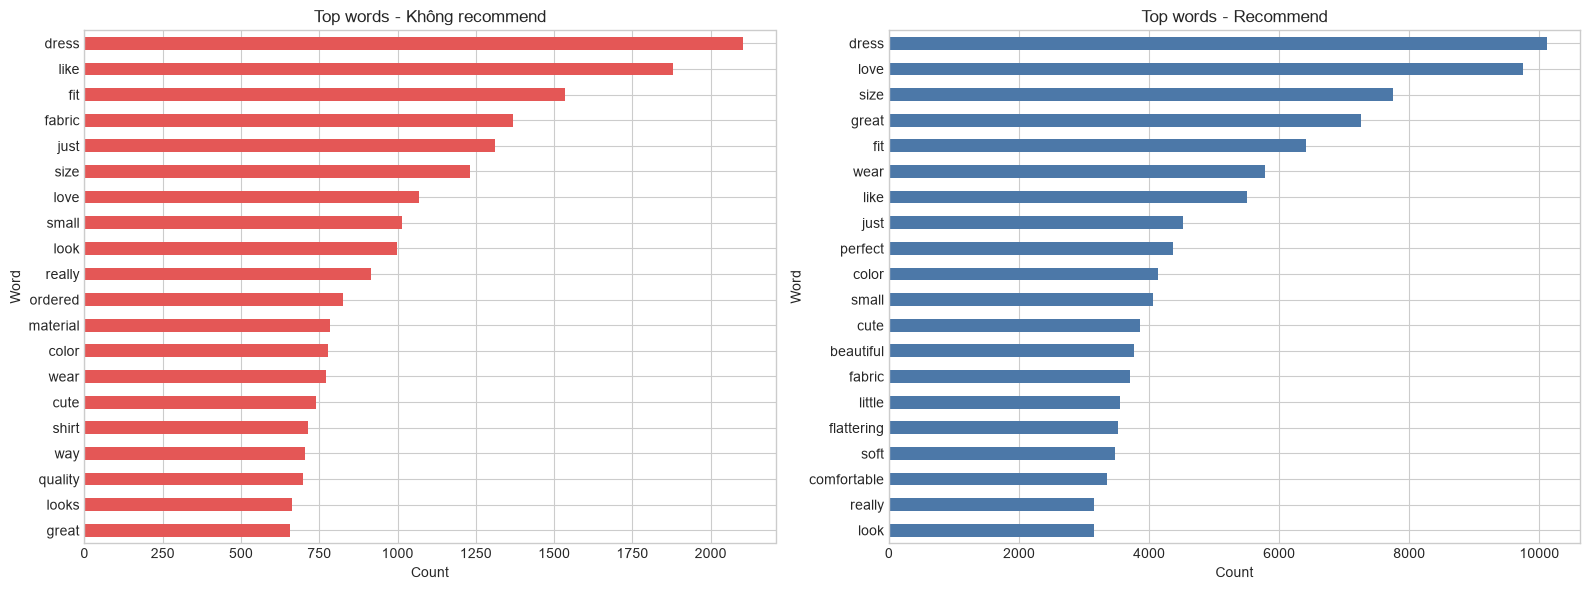

In [26]:
def top_words_by_label(texts, labels, target_label, top_n=20):
    counter = Counter()
    for text in texts[labels == target_label]:
        words = [word for word in text.split() if word not in ENGLISH_STOP_WORDS and len(word) > 2]
        counter.update(words)
    return pd.DataFrame(counter.most_common(top_n), columns=["word", "count"])


texts_array = df_model["clean_text"].to_numpy()
labels_array = df_model["label"].to_numpy()

top_negative = top_words_by_label(texts_array, labels_array, target_label=0, top_n=20)
top_positive = top_words_by_label(texts_array, labels_array, target_label=1, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_negative.sort_values("count").plot(kind="barh", x="word", y="count", ax=axes[0], color="#E45756", legend=False)
axes[0].set_title("Top words - Không recommend")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Word")

top_positive.sort_values("count").plot(kind="barh", x="word", y="count", ax=axes[1], color="#4C78A8", legend=False)
axes[1].set_title("Top words - Recommend")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Word")

plt.tight_layout()
save_current_figure("customer_comments_top_words_by_label.png")
plt.show()


## 6. Stratified Train/Test Split 80/20

Split dùng `stratify=y` để giữ tỷ lệ hai lớp gần giống nhau ở train và test.


In [27]:
X_text = df_model["clean_text"].to_numpy()
y = df_model["label"].to_numpy(dtype=int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(y_train), len(y_test)],
    "positive_rate": [y_train.mean(), y_test.mean()],
    "negative_rate": [1 - y_train.mean(), 1 - y_test.mean()],
})
display(split_summary)


,split,rows,positive_rate,negative_rate
0,train,18113,0.8189,0.1811
1,test,4529,0.8189,0.1811


## 7. TF-IDF 1,000 từ vựng chỉ fit trên Train

Đây là bước chống rò rỉ dữ liệu quan trọng: `TfidfVectorizer` chỉ gọi `fit_transform` trên `X_train_text`; tập test chỉ gọi `transform` bằng vocabulary đã học từ train.


In [28]:
MAX_FEATURES = 1000

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words="english",
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32,
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

assert X_train_tfidf.shape[1] == MAX_FEATURES, (
    f"TF-IDF phải có đúng {MAX_FEATURES} feature, hiện có {X_train_tfidf.shape[1]}"
)
assert X_test_tfidf.shape[1] == MAX_FEATURES

vocabulary = np.array(tfidf.get_feature_names_out())
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(vocabulary))
print("Ví dụ 30 từ đầu trong vocabulary:")
print(vocabulary[:30])


Train TF-IDF shape: (18113, 1000)
Test TF-IDF shape: (4529, 1000)
Vocabulary size: 1000
Ví dụ 30 từ đầu trong vocabulary:
['able' 'absolutely' 'actually' 'add' 'added' 'addition' 'adds' 'adorable'
 'adore' 'afraid' 'ag' 'ago' 'agree' 'airy' 'altered' 'amazing' 'ankle'
 'ankles' 'apart' 'appear' 'appears' 'appreciate' 'appropriate' 'area'
 'areas' 'aren' 'arm' 'armholes' 'arms' 'arrived']


,term,mean_tfidf_train
0,dress,0.0485
1,love,0.0467
2,great,0.0397
3,size,0.0376
4,fit,0.0356
5,like,0.0329
6,wear,0.0318
7,cute,0.0288
8,just,0.0285
9,small,0.0270


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/report/figures/customer_comments_top_tfidf_terms.png


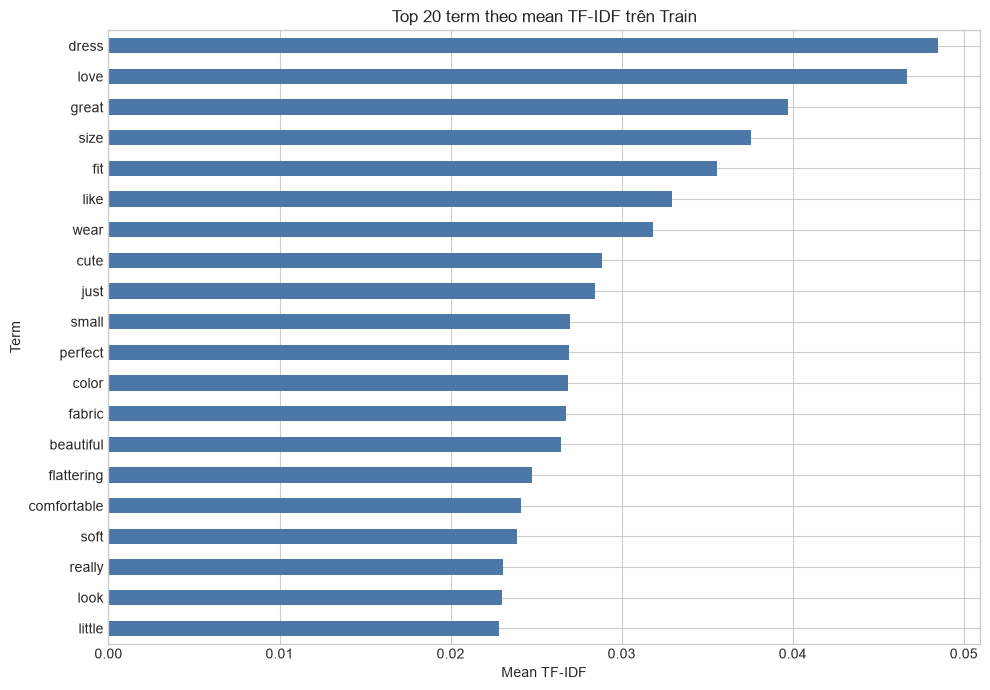

In [29]:
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_tfidf_idx = np.argsort(mean_tfidf)[-20:][::-1]
top_tfidf_df = pd.DataFrame({
    "term": vocabulary[top_tfidf_idx],
    "mean_tfidf_train": mean_tfidf[top_tfidf_idx],
})
display(top_tfidf_df)

ax = top_tfidf_df.sort_values("mean_tfidf_train").plot(
    kind="barh",
    x="term",
    y="mean_tfidf_train",
    figsize=(10, 7),
    legend=False,
    color="#4C78A8",
)
ax.set_title("Top 20 term theo mean TF-IDF trên Train")
ax.set_xlabel("Mean TF-IDF")
ax.set_ylabel("Term")
plt.tight_layout()
save_current_figure("customer_comments_top_tfidf_terms.png")
plt.show()


## 8. Hàm đánh giá benchmark classification

Tất cả mô hình được đánh giá bằng Accuracy, Precision, Recall, F1-Score, ROC-AUC, thời gian huấn luyện, thời gian dự đoán và ma trận nhầm lẫn chuẩn hóa.


In [30]:
def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def evaluate_classifier(name, y_true, y_prob, train_time, predict_time, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": safe_roc_auc(y_true, y_prob),
        "Train time (s)": train_time,
        "Predict time (s)": predict_time,
    }


def positive_probability(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


def display_classification_results(results):
    ordered_columns = [
        "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC",
        "Train time (s)", "Predict time (s)",
    ]
    results_df = pd.DataFrame(results)[ordered_columns]
    results_df = results_df.sort_values(["F1-Score", "ROC-AUC"], ascending=False).reset_index(drop=True)
    display(results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Train time (s)": "{:.3f}",
        "Predict time (s)": "{:.3f}",
    }))
    return results_df


## 9. Huấn luyện 3 mô hình Machine Learning cơ bản

Logistic Regression và Multinomial Naive Bayes dùng sparse TF-IDF trực tiếp. Random Forest dùng dense matrix vì mô hình cây thường làm việc ổn hơn với mảng dense ở quy mô này.


In [31]:
X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_test_dense = X_test_tfidf.toarray().astype(np.float32)

baseline_models = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "train_X": X_train_tfidf,
        "test_X": X_test_tfidf,
    },
    "Multinomial Naive Bayes": {
        "model": MultinomialNB(alpha=1.0),
        "train_X": X_train_tfidf,
        "test_X": X_test_tfidf,
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=100,
            max_depth=24,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "train_X": X_train_dense,
        "test_X": X_test_dense,
    },
}

benchmark_results = []
test_predictions = {}

for model_name, config in baseline_models.items():
    model = config["model"]
    train_X = config["train_X"]
    test_X = config["test_X"]

    print(f"Training {model_name}...")
    start = time.perf_counter()
    model.fit(train_X, y_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    y_prob = positive_probability(model, test_X)
    predict_time = time.perf_counter() - start

    result = evaluate_classifier(model_name, y_test, y_prob, train_time, predict_time)
    benchmark_results.append(result)
    test_predictions[model_name] = {
        "probability": y_prob,
        "prediction": (y_prob >= 0.5).astype(int),
    }

    print(f"  Test F1-Score: {result['F1-Score']:.4f}, ROC-AUC: {result['ROC-AUC']:.4f}")

baseline_results_df = display_classification_results(benchmark_results)


Training Logistic Regression...
  Test F1-Score: 0.9156, ROC-AUC: 0.9348
Training Multinomial Naive Bayes...
  Test F1-Score: 0.9212, ROC-AUC: 0.9299
Training Random Forest...
  Test F1-Score: 0.9074, ROC-AUC: 0.9016


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train time (s),Predict time (s)
0,Multinomial Naive Bayes,0.8618,0.8643,0.9860,0.9212,0.9299,0.002,0.001
1,Logistic Regression,0.8686,0.9659,0.8703,0.9156,0.9348,0.022,0.000
2,Random Forest,0.8527,0.9353,0.8811,0.9074,0.9016,0.953,0.025


## 10. MLP đa tầng thuần NumPy

MLP dưới đây không dùng TensorFlow, PyTorch, Keras hay `sklearn.neural_network`. Mạng nhận vector TF-IDF 1,000 chiều và có kiến trúc `1000 -> 64 -> 16 -> 1`.

Các thành phần chính:

- ReLU cho hidden layers
- Sigmoid cho output xác suất
- Binary cross-entropy
- Mini-batch Gradient Descent
- Class weighting để giảm ảnh hưởng mất cân bằng nhãn


In [32]:
class NumpyMLPTextClassifier:
    def __init__(
        self,
        hidden_layers=(64, 16),
        learning_rate=0.05,
        epochs=20,
        batch_size=256,
        l2=1e-4,
        random_state=42,
        verbose=True,
    ):
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.random_state = random_state
        self.verbose = verbose

    def _initialize_parameters(self, input_dim):
        rng = np.random.default_rng(self.random_state)
        layer_sizes = [input_dim, *self.hidden_layers, 1]
        self.weights = []
        self.biases = []

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            if fan_out == 1:
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                weight = rng.uniform(-limit, limit, size=(fan_in, fan_out))
            else:
                weight = rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))
            bias = np.zeros((1, fan_out))
            self.weights.append(weight.astype(np.float32))
            self.biases.append(bias.astype(np.float32))

    @staticmethod
    def _relu(x):
        return np.maximum(0.0, x)

    @staticmethod
    def _sigmoid(x):
        x = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x))

    def _set_class_weights(self, y):
        positives = np.sum(y == 1)
        negatives = np.sum(y == 0)
        total = len(y)
        if positives == 0 or negatives == 0:
            self.class_weight_ = {0: 1.0, 1: 1.0}
        else:
            self.class_weight_ = {
                0: total / (2.0 * negatives),
                1: total / (2.0 * positives),
            }

    def _forward(self, X):
        activations = [X]
        z_values = []
        current = X

        for weight, bias in zip(self.weights[:-1], self.biases[:-1]):
            z = current @ weight + bias
            current = self._relu(z)
            z_values.append(z)
            activations.append(current)

        output_z = current @ self.weights[-1] + self.biases[-1]
        output = self._sigmoid(output_z)
        z_values.append(output_z)
        activations.append(output)

        return output, {"activations": activations, "z_values": z_values}

    def _weighted_bce(self, y_true, y_prob):
        y_true = y_true.reshape(-1, 1).astype(np.float32)
        y_prob = np.clip(y_prob, 1e-7, 1 - 1e-7)
        sample_weights = np.where(y_true == 1, self.class_weight_[1], self.class_weight_[0]).astype(np.float32)
        data_loss = -np.mean(sample_weights * (y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)))
        regularization = 0.5 * self.l2 * sum(np.sum(weight ** 2) for weight in self.weights)
        return float(data_loss + regularization)

    def _backward(self, y_batch, cache):
        y_batch = y_batch.reshape(-1, 1).astype(np.float32)
        batch_size = len(y_batch)
        activations = cache["activations"]
        z_values = cache["z_values"]

        sample_weights = np.where(y_batch == 1, self.class_weight_[1], self.class_weight_[0]).astype(np.float32)
        d_z = sample_weights * (activations[-1] - y_batch) / batch_size

        grad_weights = [None] * len(self.weights)
        grad_biases = [None] * len(self.biases)

        for layer_idx in reversed(range(len(self.weights))):
            previous_activation = activations[layer_idx]
            grad_weights[layer_idx] = previous_activation.T @ d_z + self.l2 * self.weights[layer_idx]
            grad_biases[layer_idx] = np.sum(d_z, axis=0, keepdims=True)

            if layer_idx > 0:
                d_activation = d_z @ self.weights[layer_idx].T
                d_z = d_activation * (z_values[layer_idx - 1] > 0)

        return grad_weights, grad_biases

    def fit(self, X_train, y_train):
        X_train = X_train.astype(np.float32, copy=False)
        y_train = y_train.astype(np.float32)

        self._initialize_parameters(input_dim=X_train.shape[1])
        self._set_class_weights(y_train)
        rng = np.random.default_rng(self.random_state)
        self.history_ = []

        for epoch in range(1, self.epochs + 1):
            shuffled_indices = rng.permutation(len(X_train))
            batch_losses = []

            for start in range(0, len(X_train), self.batch_size):
                batch_indices = shuffled_indices[start:start + self.batch_size]
                X_batch = X_train[batch_indices]
                y_batch = y_train[batch_indices]

                y_prob, cache = self._forward(X_batch)
                batch_losses.append(self._weighted_bce(y_batch, y_prob))
                grad_weights, grad_biases = self._backward(y_batch, cache)

                for layer_idx in range(len(self.weights)):
                    self.weights[layer_idx] -= self.learning_rate * grad_weights[layer_idx]
                    self.biases[layer_idx] -= self.learning_rate * grad_biases[layer_idx]

            train_prob = self.predict_proba(X_train)
            train_pred = (train_prob >= 0.5).astype(int)
            epoch_record = {
                "epoch": epoch,
                "train_loss": float(np.mean(batch_losses)),
                "train_accuracy": accuracy_score(y_train, train_pred),
                "train_f1": f1_score(y_train, train_pred, zero_division=0),
            }
            self.history_.append(epoch_record)

            if self.verbose and (epoch == 1 or epoch % 5 == 0 or epoch == self.epochs):
                print(
                    f"Epoch {epoch:03d} | "
                    f"loss={epoch_record['train_loss']:.4f} | "
                    f"train_acc={epoch_record['train_accuracy']:.4f} | "
                    f"train_f1={epoch_record['train_f1']:.4f}"
                )
        return self

    def predict_proba(self, X):
        X = X.astype(np.float32, copy=False)
        probability, _ = self._forward(X)
        return probability.ravel()


## 11. Huấn luyện MLP NumPy

Cell này có thể chạy lâu hơn các mô hình ML cơ bản vì toàn bộ forward/backpropagation được viết bằng NumPy thuần.


In [33]:
mlp = NumpyMLPTextClassifier(
    hidden_layers=(64, 16),
    learning_rate=0.05,
    epochs=20,
    batch_size=256,
    l2=1e-4,
    random_state=RANDOM_STATE,
    verbose=True,
)

start = time.perf_counter()
mlp.fit(X_train_dense, y_train)
mlp_train_time = time.perf_counter() - start

start = time.perf_counter()
mlp_y_prob = mlp.predict_proba(X_test_dense)
mlp_predict_time = time.perf_counter() - start

mlp_result = evaluate_classifier(
    "NumPy MLP (1000-64-16-1)",
    y_test,
    mlp_y_prob,
    mlp_train_time,
    mlp_predict_time,
)

benchmark_results.append(mlp_result)
test_predictions["NumPy MLP (1000-64-16-1)"] = {
    "probability": mlp_y_prob,
    "prediction": (mlp_y_prob >= 0.5).astype(int),
}

print(f"Test F1-Score: {mlp_result['F1-Score']:.4f}, ROC-AUC: {mlp_result['ROC-AUC']:.4f}")


Epoch 001 | loss=0.7007 | train_acc=0.5058 | train_f1=0.6133
Epoch 005 | loss=0.6911 | train_acc=0.6987 | train_f1=0.7913
Epoch 010 | loss=0.6177 | train_acc=0.7787 | train_f1=0.8482
Epoch 015 | loss=0.4049 | train_acc=0.8577 | train_f1=0.9079
Epoch 020 | loss=0.3274 | train_acc=0.8755 | train_f1=0.9202
Test F1-Score: 0.9091, ROC-AUC: 0.9297


## 12. Learning curve của MLP

Biểu đồ giúp kiểm tra MLP học ổn định không qua từng epoch.


,epoch,train_loss,train_accuracy,train_f1
15,16,0.3784,0.8662,0.9140
16,17,0.3593,0.8420,0.8958
17,18,0.3457,0.8849,0.9274
18,19,0.3361,0.8374,0.8919
19,20,0.3274,0.8755,0.9202


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/report/figures/customer_comments_mlp_learning_curve.png


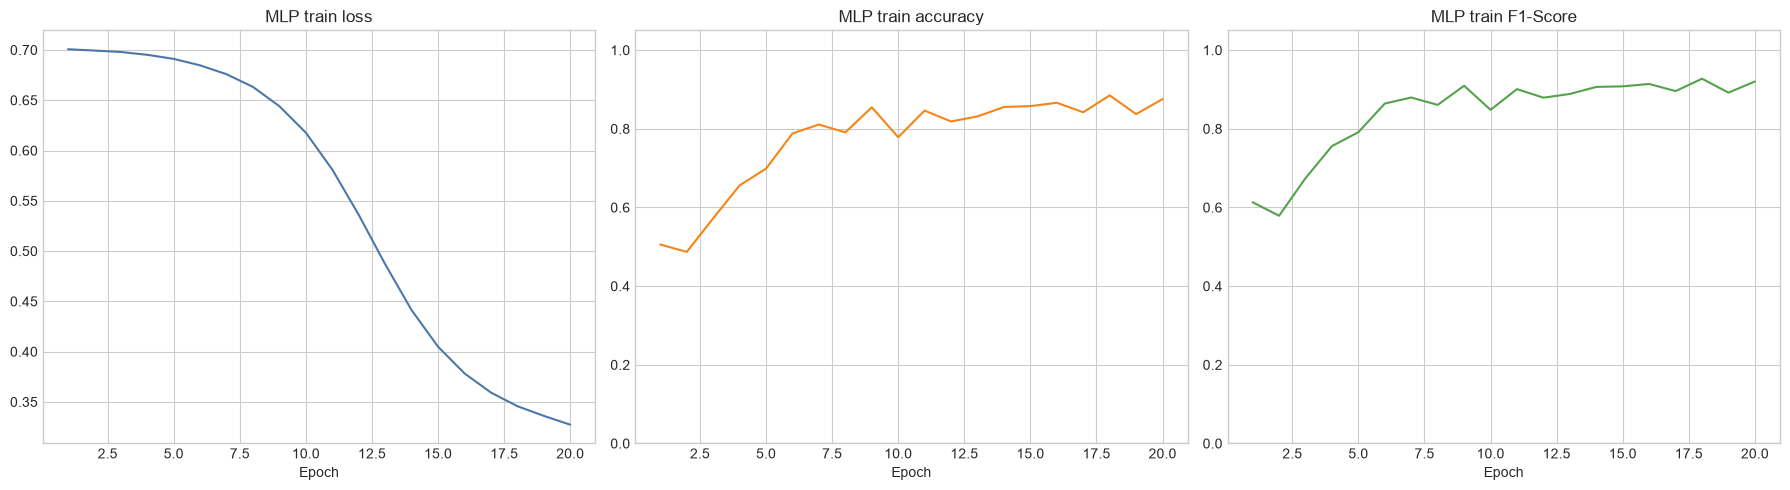

In [34]:
history_df = pd.DataFrame(mlp.history_)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], color="#4C78A8")
axes[0].set_title("MLP train loss")
axes[0].set_xlabel("Epoch")

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], color="#F58518")
axes[1].set_title("MLP train accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1.05)

axes[2].plot(history_df["epoch"], history_df["train_f1"], color="#54A24B")
axes[2].set_title("MLP train F1-Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
save_current_figure("customer_comments_mlp_learning_curve.png")
plt.show()


## 13. Benchmark toàn diện 4 mô hình

Bảng dưới đây là kết quả trên test set. Vì nhãn mất cân bằng, cần đọc Accuracy cùng Precision, Recall, F1-Score và ROC-AUC.


In [35]:
results_df = display_classification_results(benchmark_results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train time (s),Predict time (s)
0,Multinomial Naive Bayes,0.8618,0.8643,0.9860,0.9212,0.9299,0.002,0.001
1,Logistic Regression,0.8686,0.9659,0.8703,0.9156,0.9348,0.022,0.000
2,NumPy MLP (1000-64-16-1),0.8591,0.9640,0.8601,0.9091,0.9297,0.691,0.002
3,Random Forest,0.8527,0.9353,0.8811,0.9074,0.9016,0.953,0.025


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train time (s),Predict time (s)
0,Multinomial Naive Bayes,0.8618,0.8643,0.9860,0.9212,0.9299,0.0020,0.0007
1,Logistic Regression,0.8686,0.9659,0.8703,0.9156,0.9348,0.0222,0.0005
2,NumPy MLP (1000-64-16-1),0.8591,0.9640,0.8601,0.9091,0.9297,0.6906,0.0019
3,Random Forest,0.8527,0.9353,0.8811,0.9074,0.9016,0.9528,0.0253


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/report/figures/customer_comments_metric_comparison.png


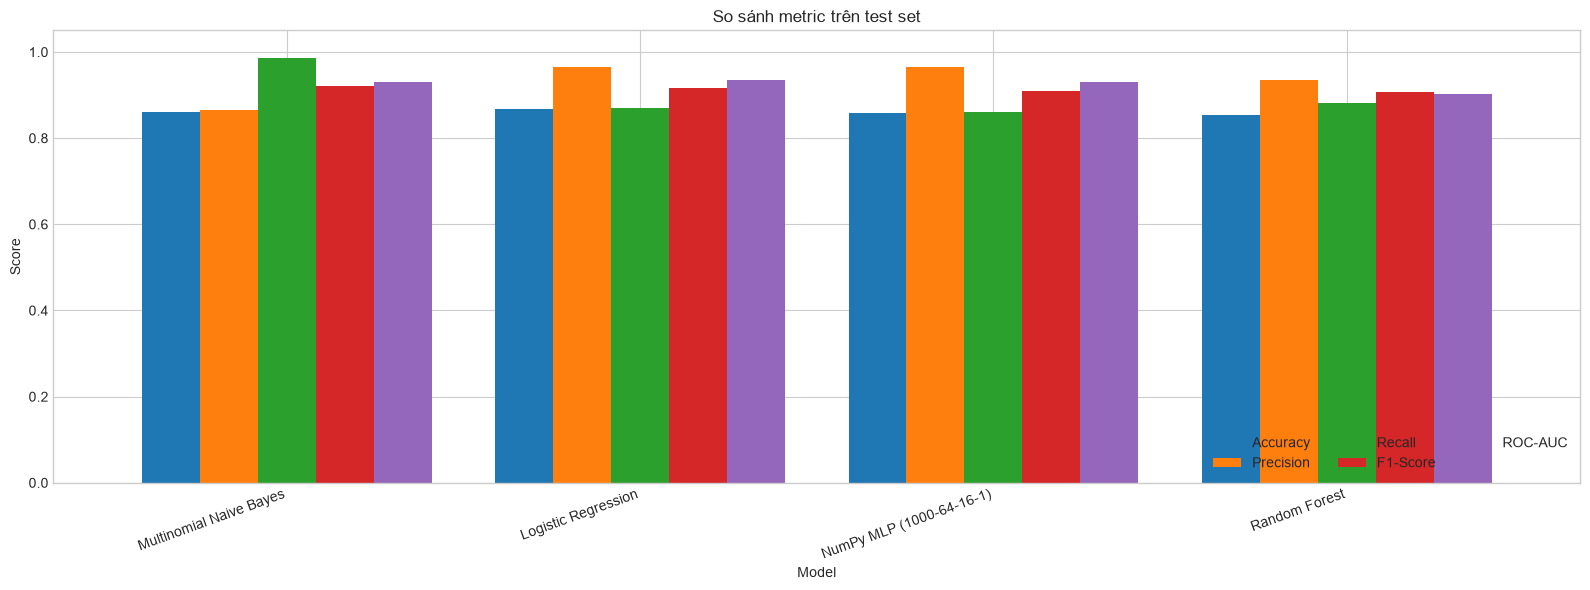

In [36]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

plot_df = results_df.set_index("Model")[metric_cols]
ax = plot_df.plot(kind="bar", figsize=(16, 6), width=0.82)
ax.set_title("So sánh metric trên test set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_current_figure("customer_comments_metric_comparison.png")
plt.show()


## 14. Ma trận nhầm lẫn chuẩn hóa

Ma trận được normalize theo từng hàng (`normalize="true"`), nên mỗi hàng thể hiện tỷ lệ dự đoán của một nhãn thật.


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/customer_comments/report/figures/customer_comments_normalized_confusion_matrices.png


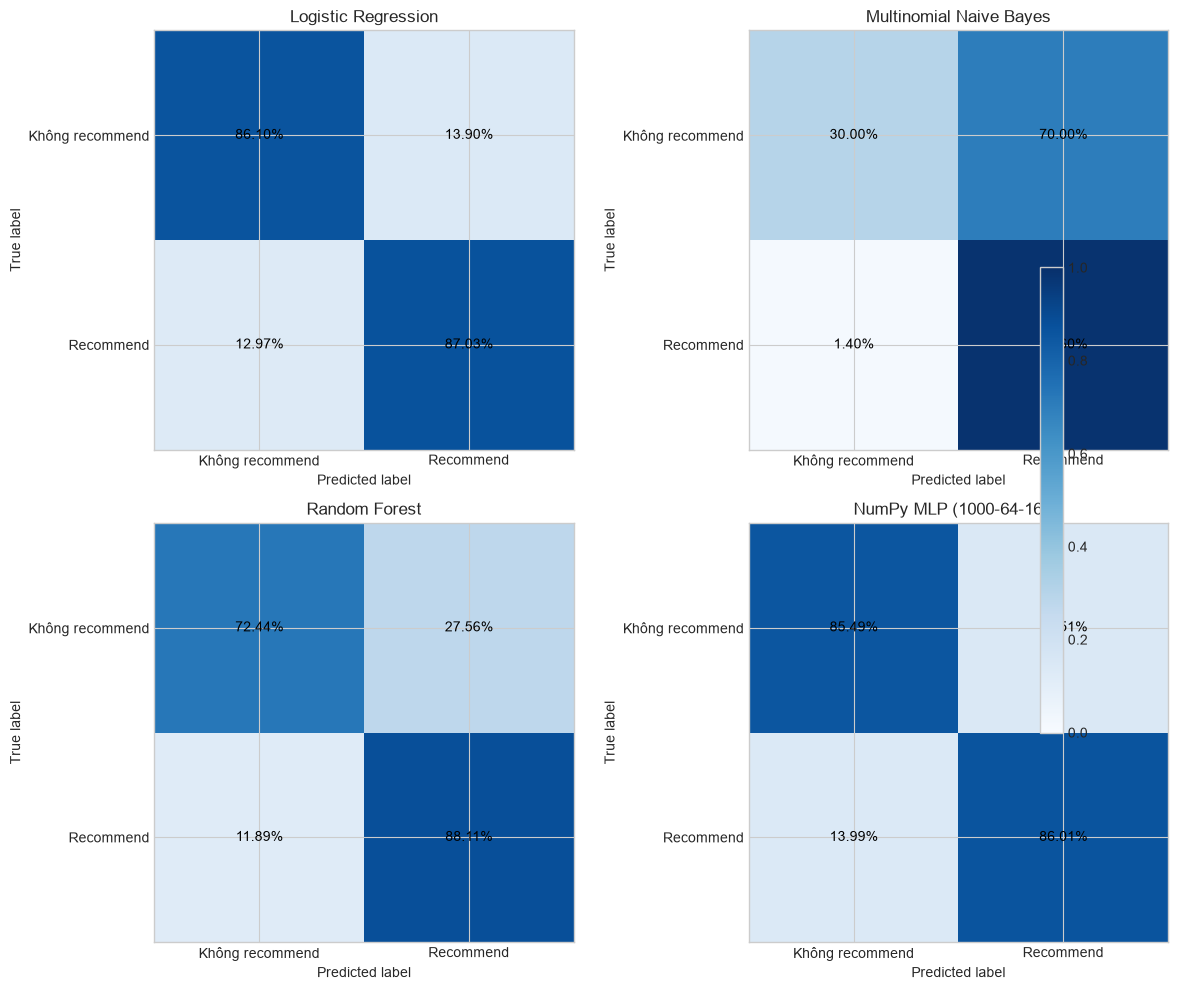

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (model_name, prediction_info) in zip(axes, test_predictions.items()):
    matrix = confusion_matrix(y_test, prediction_info["prediction"], normalize="true")
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Không recommend", "Recommend"])
    ax.set_yticklabels(["Không recommend", "Recommend"])

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, f"{matrix[row, col]:.2%}", ha="center", va="center", color="black")

fig.colorbar(image, ax=axes.tolist(), fraction=0.025, pad=0.02)
plt.tight_layout()
save_current_figure("customer_comments_normalized_confusion_matrices.png")
plt.show()


## 15. Kiểm tra một vài dự đoán sai

Phần này giúp đọc lại các review mà mô hình tốt nhất dự đoán sai, từ đó hiểu lỗi đến từ câu mơ hồ, review quá ngắn hay văn phong trái ngược.


In [38]:
best_model_name = results_df.iloc[0]["Model"]
best_pred = test_predictions[best_model_name]["prediction"]
best_prob = test_predictions[best_model_name]["probability"]

mistakes = pd.DataFrame({
    "text": X_test_text,
    "true_label": y_test,
    "pred_label": best_pred,
    "prob_recommend": best_prob,
})
mistakes = mistakes[mistakes["true_label"] != mistakes["pred_label"]].copy()
mistakes["confidence"] = np.where(mistakes["pred_label"] == 1, mistakes["prob_recommend"], 1 - mistakes["prob_recommend"])
mistakes = mistakes.sort_values("confidence", ascending=False)

print(f"Best model theo F1-Score: {best_model_name}")
print(f"Số mẫu dự đoán sai: {len(mistakes):,} / {len(y_test):,}")
display(mistakes.head(10))


Best model theo F1-Score: Multinomial Naive Bayes
Số mẫu dự đoán sai: 626 / 4,529


,text,true_label,pred_label,prob_recommend,confidence
2634,love it i didn t realize how much i would love this wore it to work the other day and got more compliments than i ha...,0,1,0.9863,0.9863
3076,beautiful jacket and well made i bought this jacket in a regular and returned it to the store where they had a petit...,0,1,0.9781,0.9781
1478,love this dress i also have this dress in sleeve tegan tunic i love this dress it can be dressed up or down,0,1,0.9617,0.9617
3946,thin layering turtleneck i ordered this turtleneck in white and was very surprised to find that the material is so t...,0,1,0.9504,0.9504
1796,love this top this top is one of my retailer faves it is so comfortable and love the quality and design i receive ma...,0,1,0.9477,0.9477
3417,too thin too sheer i have been looking for a nice white top to go with many of my skirts for summer and this is not ...,0,1,0.9428,0.9428
1728,presses all the wrong buttons this coat is so lovely it is the embodiment of s classic movie star style the color th...,0,1,0.9421,0.9421
4403,does really run large i found this dress to run large like the other reviewers have mentioned the quality is really ...,0,1,0.9414,0.9414
1845,beautiful but extremely see thru the design is gorgeous the fit is great and the fabric drapes beautifully and is ve...,0,1,0.9365,0.9365
1505,please stop going down in fabric quality i ve been wearing these shorts for years i work outside and it was great to...,0,1,0.9262,0.9262


## 16. Kết luận

Accuracy có thể cao vì nhãn `Recommend` chiếm đa số. Vì vậy phần kết luận ưu tiên F1-Score và ROC-AUC để đánh giá khả năng phân biệt hai lớp toàn diện hơn.


In [39]:
best_by_f1 = results_df.sort_values("F1-Score", ascending=False).iloc[0]
best_by_auc = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]

print("Kết luận benchmark:")
print(f"- Mô hình tốt nhất theo F1-Score: {best_by_f1['Model']} ({best_by_f1['F1-Score']:.4f})")
print(f"- Mô hình tốt nhất theo ROC-AUC: {best_by_auc['Model']} ({best_by_auc['ROC-AUC']:.4f})")
print("- TF-IDF được fit nghiêm ngặt trên Train, Test chỉ transform để chống rò rỉ dữ liệu.")
print("- MLP NumPy dùng đúng kiến trúc 1000 -> 64 -> 16 -> 1 và huấn luyện bằng mini-batch gradient descent.")

display(results_df)


Kết luận benchmark:
- Mô hình tốt nhất theo F1-Score: Multinomial Naive Bayes (0.9212)
- Mô hình tốt nhất theo ROC-AUC: Logistic Regression (0.9348)
- TF-IDF được fit nghiêm ngặt trên Train, Test chỉ transform để chống rò rỉ dữ liệu.
- MLP NumPy dùng đúng kiến trúc 1000 -> 64 -> 16 -> 1 và huấn luyện bằng mini-batch gradient descent.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train time (s),Predict time (s)
0,Multinomial Naive Bayes,0.8618,0.8643,0.9860,0.9212,0.9299,0.0020,0.0007
1,Logistic Regression,0.8686,0.9659,0.8703,0.9156,0.9348,0.0222,0.0005
2,NumPy MLP (1000-64-16-1),0.8591,0.9640,0.8601,0.9091,0.9297,0.6906,0.0019
3,Random Forest,0.8527,0.9353,0.8811,0.9074,0.9016,0.9528,0.0253
